# BNPL Merchant Ranking — Top 100 Overall

**Purpose:** Rank merchants for BNPL onboarding using historical transaction value, customer reach, activity, loyalty, and observed fraud indicators. 

**Inputs:** `data/curated/merchant_features/merchant_features.parquet` (one row per merchant). **Outputs:** complete rankings and Top 100 CSV/Parquet in `data/curated/merchant_rankings/`.

**Business interpretation:** Transaction value is a proxy for potential fee-generating volume, **not BNPL revenue** (take rate unknown). Scores are relative to the observed merchant population; the weights are initial assumptions to test, not empirically optimized.

## 1. Load merchant-level data (no large transaction files)

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'curated' / 'merchant_features' / 'merchant_features.parquet').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Cannot find data/curated/merchant_features/merchant_features.parquet; check your notebook working directory.')
INPUT = ROOT / 'data' / 'curated' / 'merchant_features' / 'merchant_features.parquet'
OUTPUT_DIR = ROOT / 'data' / 'curated' / 'merchant_rankings'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
merchants = pd.read_parquet(INPUT)
print('Loaded:', INPUT)
print('Shape:', merchants.shape)
print('Unique ABNs:', merchants['merchant_abn'].nunique())
display(merchants.head(3))

Loaded: /Users/amyliu/Desktop/MAST30034_Project_2/data/curated/merchant_features/merchant_features.parquet
Shape: (4422, 45)
Unique ABNs: 4422


,merchant_abn,total_transaction_value,transaction_count,unique_customers,avg_transaction_value,median_transaction_value,std_transaction_value,max_transaction_value,first_transaction,last_transaction,...,repeat_customer_share,largest_customer_value,largest_customer_value_share,name_merchant,tags,unique_customer_states,unique_customer_sa2s,customer_mean_disadvantage_score,customer_mean_economic_resources_score,predicted_3m_revenue
0,28000487688,9.270055e+05,3791,3495,244.527973,191.942442,201.295657,1526.831103,2021-02-28,2022-10-26,...,0.079256,1843.153553,0.001988,Sed Nunc Industries,"((books, periodicals, anD newspapers), (b), (t...",8,1123,991.960572,994.899205,191109.851956
1,62191208634,1.423276e+06,16380,11863,86.891108,60.327717,87.130348,786.934322,2021-02-28,2022-10-26,...,0.301610,1062.530781,0.000747,Cursus Non Egestas Foundation,"[(furniture, home furnishings and equipment sh...",8,1465,991.862544,994.664210,239383.980583
2,83690644458,3.183224e+06,35852,18665,88.787899,89.039687,33.785628,146.998662,2021-02-28,2022-10-26,...,0.565229,861.718216,0.000271,Id Erat Etiam Consulting,"[(gift, card, novelty, and souvenir shops), (b...",8,1489,992.027650,994.943490,630877.236102


## 2. Validate inputs and audit fraud coverage

Zero missingness in the selected ranking fields is useful, but **fraud-flag coverage is a different issue**: a recorded zero risk with poor coverage is not evidence of safety.

In [31]:
REQUIRED = ['merchant_abn','total_transaction_value','unique_customers',
            'transactions_per_active_month','repeat_customer_share',
            'observed_any_fraud_flag_rate','fraud_flag_coverage','transaction_count', 'predicted_3m_revenue']
missing_cols = sorted(set(REQUIRED) - set(merchants.columns))
if missing_cols:
    raise ValueError(f'Missing required merchant feature columns: {missing_cols}')
if merchants['merchant_abn'].isna().any() or merchants['merchant_abn'].duplicated().any():
    raise ValueError('Expected exactly one non-null row per merchant_abn.')
for col in REQUIRED[1:]:
    merchants[col] = pd.to_numeric(merchants[col], errors='coerce')
    merchants[col] = merchants[col].replace([np.inf, -np.inf], np.nan)
print('Missing / invalid required values:')
print(merchants[REQUIRED].isna().sum().to_string())
for col in ['repeat_customer_share','observed_any_fraud_flag_rate','fraud_flag_coverage']:
    if not merchants[col].dropna().between(0, 1).all():
        raise ValueError(f'{col} has values outside [0,1].')
if (merchants['transaction_count'] <= 0).any():
    raise ValueError('transaction_count must be positive.')
print('Fraud coverage summary:')
display(merchants['fraud_flag_coverage'].describe().to_frame('fraud_flag_coverage'))

Missing / invalid required values:
merchant_abn                      0
total_transaction_value           0
unique_customers                  0
transactions_per_active_month     0
repeat_customer_share             0
observed_any_fraud_flag_rate      0
fraud_flag_coverage               0
transaction_count                 0
predicted_3m_revenue             37
Fraud coverage summary:


,fraud_flag_coverage
count,4422.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


## 3. Define scoring policy

**Weights:** historical transaction value 30%, unique customers 25%, transactions per active month 20%, repeat-customer share 15%, observed fraud risk 10%.

- Monetary volume and frequency use `log1p` (large merchants otherwise dominate), then **percentile ranks** across merchants to obtain comparable 0–1 scores.
- Repeat-customer share is percentile-ranked; the risk score uses **the raw observed flagged rate** (0–1) so a tiny difference in low fraud rates is not magnified by percentile ranking.
- **Fraud penalty:** a larger observed flagged rate reduces the score. All merchants stay eligible.
- **Review flags:** configurable risk and low-coverage thresholds, not claims of confirmed fraud. A low-coverage merchant is flagged for data review rather than assumed risk-free.
- Missing commercial values receive the median score (neutral); missing fraud rates receive no observed-risk penalty but trigger review. Thresholds and weights are policy choices for sensitivity testing.

In [32]:
WEIGHTS = {
    'predicted_revenue': 0.25,
    'revenue': 0.15,
    'customers': 0.20,
    'frequency': 0.15,
    'loyalty': 0.15,
    'fraud': 0.10,
}
assert np.isclose(sum(WEIGHTS.values()), 1.0)

# Initial screening thresholds; adjust after inspecting distributions.
HIGH_FRAUD_RATE = 0.05      # 5% of observed transactions flagged
LOW_FRAUD_COVERAGE = 0.80  # <80% of transactions have a known flag
MIN_TRANSACTIONS_FOR_CONFIDENCE = 30

def percentile_score(series, log_transform=False):
    x = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan)
    if log_transform:
        x = np.log1p(x.clip(lower=0))
    score = x.rank(pct=True, method='average')
    return score.fillna(0.5)

def rank_merchants(df, weights=WEIGHTS):
    if not np.isclose(sum(weights.values()), 1.0):
        raise ValueError('Ranking weights must sum to 1.')
    out = df.copy()
    out['revenue_score'] = percentile_score(out['total_transaction_value'], log_transform=True)
    out['customer_score'] = percentile_score(out['unique_customers'], log_transform=True)
    out['frequency_score'] = percentile_score(out['transactions_per_active_month'], log_transform=True)
    out['loyalty_score'] = percentile_score(out['repeat_customer_share'])
    out['fraud_rate_used'] = out['observed_any_fraud_flag_rate'].clip(0, 1)
    out['fraud_score'] = 1 - out['fraud_rate_used'].fillna(0)
    out['fraud_risk_flag'] = out['fraud_rate_used'].ge(HIGH_FRAUD_RATE).fillna(False)
    out['fraud_data_review_flag'] = (out['fraud_flag_coverage'].lt(LOW_FRAUD_COVERAGE) |
                                     out['fraud_rate_used'].isna()).fillna(True)
    out['low_history_flag'] = out['transaction_count'].lt(MIN_TRANSACTIONS_FOR_CONFIDENCE)
    out['manual_review_flag'] = (out['fraud_risk_flag'] | out['fraud_data_review_flag'] |
                                 out['low_history_flag'])
    out['predicted_revenue_score'] = percentile_score(
    out['predicted_3m_revenue'],
    log_transform=True)

    out['ranking_score'] = 100 * (
    weights['predicted_revenue'] * out['predicted_revenue_score'] +
    weights['revenue'] * out['revenue_score'] +
    weights['customers'] * out['customer_score'] +
    weights['frequency'] * out['frequency_score'] +
    weights['loyalty'] * out['loyalty_score'] +
    weights['fraud'] * out['fraud_score'])
    
    out = out.sort_values(['ranking_score','total_transaction_value','merchant_abn'],
                          ascending=[False,False,True], kind='stable').reset_index(drop=True)
    out.insert(0, 'overall_rank', np.arange(1, len(out) + 1))
    return out

ranked = rank_merchants(merchants)
print('Total merchants ranked:', len(ranked))
print('High observed fraud risk:', int(ranked['fraud_risk_flag'].sum()))
print('Fraud data review:', int(ranked['fraud_data_review_flag'].sum()))
print('Manual review (any reason):', int(ranked['manual_review_flag'].sum()))

Total merchants ranked: 4422
High observed fraud risk: 8
Fraud data review: 0
Manual review (any reason): 568


## 4. Top 100 merchants and explanations

In [33]:
SHOW = ['overall_rank','merchant_abn']
for c in ['name_merchant','tags']:
    if c in ranked.columns: SHOW.append(c)
SHOW += ['ranking_score','total_transaction_value','unique_customers',
         'transactions_per_active_month','repeat_customer_share',
         'observed_any_fraud_flag_rate','fraud_flag_coverage',
         'fraud_risk_flag','fraud_data_review_flag','manual_review_flag']
top_100 = ranked.head(100).copy()
display(top_100[SHOW].head(20).round(3))
print('Top 100 flagged for manual review:', int(top_100['manual_review_flag'].sum()))
print('Top 100 observed transaction value:', f"${top_100['total_transaction_value'].sum():,.2f}")

,overall_rank,merchant_abn,name_merchant,tags,ranking_score,total_transaction_value,unique_customers,transactions_per_active_month,repeat_customer_share,observed_any_fraud_flag_rate,fraud_flag_coverage,fraud_risk_flag,fraud_data_review_flag,manual_review_flag
0,1,64203420245,Pede Nonummy Corp.,"((tent and awning shops), (c), (take rate: 2.86))",99.789,7549445.230,24081,12418.095,1.000,0.0,1.0,False,False,False
1,2,24852446429,Erat Vitae LLP,"[(florists supplies, nursery stock, and floWer...",99.711,8698779.502,24080,13786.333,1.000,0.0,1.0,False,False,False
2,3,46804135891,Suspendisse Dui Corporation,"((opticians, optical goods, and eyeglasses), (...",99.689,7042649.813,24079,11163.524,1.000,0.0,1.0,False,False,False
3,4,60956456424,Ultricies Dignissim LLP,"([gift, card, Novelty, and souvenir shops], [b...",99.648,8026970.724,23499,4319.286,0.911,0.0,1.0,False,False,False
4,5,32234779638,None,None,99.645,8745123.708,23913,5560.619,0.962,0.0,1.0,False,False,False
5,6,64403598239,Lobortis Ultrices Company,"((music shops - musical instruments, pianos, a...",99.596,8873434.487,23875,5406.714,0.957,0.0,1.0,False,False,False
6,7,80324045558,Ipsum Dolor Sit Corporation,"[(gift, card, novelty, and souvenir shops), (c...",99.591,7219970.063,24076,9373.333,0.997,0.0,1.0,False,False,False
7,8,79417999332,Phasellus At Company,"([gift, card, novelty, and souvenIr shops], [b...",99.557,9126402.797,23731,4725.048,0.932,0.0,1.0,False,False,False
8,9,49891706470,Non Vestibulum Industries,"((teNt and awning shops), (a), (take rate: 5.80))",99.539,7171594.314,24078,11786.952,1.000,0.0,1.0,False,False,False
9,10,86578477987,Leo In Consulting,"[[watch, clock, and jewelry repair shops], [a]...",99.519,9539822.773,24081,12984.476,1.000,0.0,1.0,False,False,False


Top 100 flagged for manual review: 0
Top 100 observed transaction value: $637,745,393.71


## 5. Visualise rankings and risk

These figures can be reused in the Sprint 6 summary notebook. Interpret differences as descriptive associations, not causal effects.

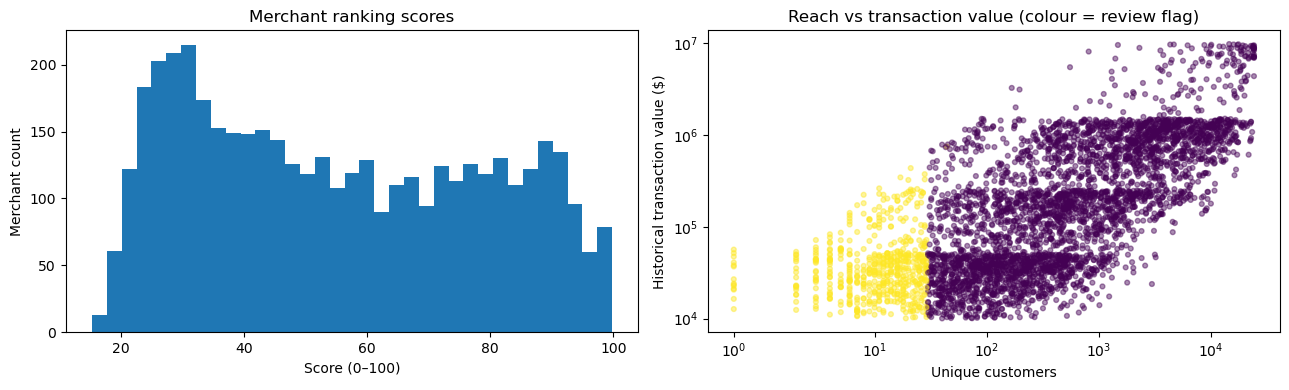

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ranked['ranking_score'].dropna(), bins=35)
axes[0].set(title='Merchant ranking scores', xlabel='Score (0–100)', ylabel='Merchant count')
axes[1].scatter(ranked['unique_customers'], ranked['total_transaction_value'],
                c=ranked['manual_review_flag'].astype(int), alpha=0.45, s=12)
axes[1].set(xscale='symlog', yscale='symlog', xlabel='Unique customers',
            ylabel='Historical transaction value ($)',
            title='Reach vs transaction value (colour = review flag)')
plt.tight_layout()
plt.show()

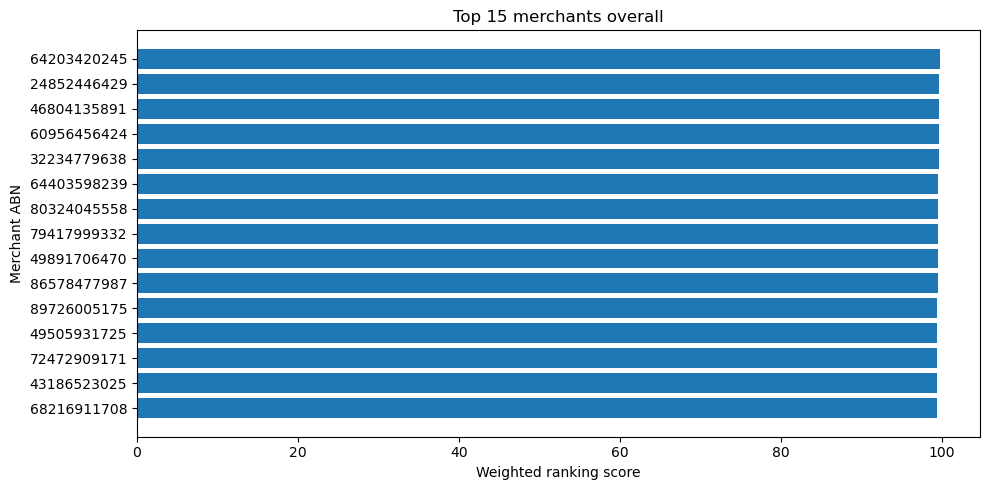

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = top_100.head(15).sort_values('ranking_score')
ax.barh(plot_data['merchant_abn'].astype(str), plot_data['ranking_score'])
ax.set(xlabel='Weighted ranking score', ylabel='Merchant ABN', title='Top 15 merchants overall')
plt.tight_layout()
plt.show()

## 6. Sensitivity analysis

Compare the baseline Top 100 against alternative weights. A high overlap suggests the shortlist is not overly dependent on one subjective weighting scheme. All scenarios preserve a fraud penalty and the same review flags.

In [36]:
SCENARIOS = {
    'baseline': {
        'predicted_revenue': 0.25,
        'revenue': 0.15,
        'customers': 0.20,
        'frequency': 0.15,
        'loyalty': 0.15,
        'fraud': 0.10
    },
    'revenue_focused': {
        'predicted_revenue': 0.35,
        'revenue': 0.25,
        'customers': 0.15,
        'frequency': 0.10,
        'loyalty': 0.10,
        'fraud': 0.05
    },
    'customer_focused': {
        'predicted_revenue': 0.15,
        'revenue': 0.10,
        'customers': 0.30,
        'frequency': 0.20,
        'loyalty': 0.20,
        'fraud': 0.05
    },
    'risk_conscious': {
        'predicted_revenue': 0.20,
        'revenue': 0.10,
        'customers': 0.15,
        'frequency': 0.15,
        'loyalty': 0.15,
        'fraud': 0.25
    }
}
base_set = set(top_100['merchant_abn'])
rows = []
for name, weights in SCENARIOS.items():
    scenario = rank_merchants(merchants, weights)
    scenario_set = set(scenario.head(100)['merchant_abn'])
    rows.append({'scenario': name, 'top_100_overlap_with_baseline': len(base_set & scenario_set),
                 'overlap_percent': 100 * len(base_set & scenario_set) / max(1, len(base_set))})
sensitivity = pd.DataFrame(rows)
display(sensitivity)
print('Interpretation: lower overlap means ranking decisions are more sensitive to the chosen weights.')

,scenario,top_100_overlap_with_baseline,overlap_percent
0,baseline,100,100.0
1,revenue_focused,94,94.0
2,customer_focused,90,90.0
3,risk_conscious,98,98.0


Interpretation: lower overlap means ranking decisions are more sensitive to the chosen weights.


## 7. Export rankings

This notebook deliberately does **not** segment merchants yet. Next: select 3–5 meaningful groups using `tags` and produce a Top 10 within each. These exports are the inputs for the final summary notebook.

In [37]:
assert ranked['merchant_abn'].is_unique
assert len(top_100) == min(100, len(ranked))
assert ranked['ranking_score'].between(0, 100.000001).all()
ranked.to_parquet(OUTPUT_DIR / 'merchant_rankings_all.parquet', index=False)
ranked.to_csv(OUTPUT_DIR / 'merchant_rankings_all.csv', index=False)
top_100.to_csv(OUTPUT_DIR / 'top_100_merchants.csv', index=False)
top_100.to_parquet(OUTPUT_DIR / 'top_100_merchants.parquet', index=False)
sensitivity.to_csv(OUTPUT_DIR / 'ranking_sensitivity.csv', index=False)
print('Saved outputs to:', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob('*')):
    print(' -', p.name)

Saved outputs to: /Users/amyliu/Desktop/MAST30034_Project_2/data/curated/merchant_rankings
 - merchant_rankings_all.csv
 - merchant_rankings_all.parquet
 - ranking_sensitivity.csv
 - top_100_merchants.csv
 - top_100_merchants.parquet


## 8. notes to add

1. **Objective:** Prioritise merchants with strong fee-generating transaction volume, broad customer reach, consistent activity and repeat purchasing, while accounting for observed fraud exposure.
2. **Method:** A 100-point weighted score using comparable percentile-based commercial features and a raw-rate fraud penalty. All merchants remain ranked; risk and data-quality flags indicate where due diligence is required.

3. **Results:** Report the actual Top 100 and key patterns from the tables/plots above; 

4. **Limitations:** Historical volume is not net BNPL revenue; fraud flags are not confirmed fraud losses; coverage may be incomplete; correlated commercial features may double-count scale; the weights and thresholds are judgement-based.

